# Cuaderno 02: Modelo de Clasificación - Predicción de Mortalidad en UCI

**Objetivo:** Desarrollar, entrenar y evaluar un modelo de aprendizaje automático supervisado capaz de predecir el riesgo de fallecimiento de un paciente durante su ingreso en la unidad de cuidados intensivos, utilizando las variables demográficas, clínicas y de gravedad al ingreso.

---

## 1. Importación de Librerías
Carga de las herramientas necesarias para la manipulación de la matriz de datos y la partición del *dataset*.

In [20]:
# Importación de librerías base
import pandas as pd
import numpy as np
import warnings

import os
import sys
import tempfile
import subprocess
import joblib

# Herramientas de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, f_classif
from sklearn.preprocessing import OneHotEncoder

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1.1. Importación de librerías de modelado

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, precision_recall_curve
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías de modelado importadas correctamente.")

Librerías de modelado importadas correctamente.


## 2. Definición de Variables, Partición y Codificación Categórica

En esta sección se separa el *target* de la matriz predictora, se particiona el dataset **antes** de codificar (para que el encoder solo aprenda categorías del conjunto de entrenamiento) y finalmente se aplica *One-Hot Encoding*.

### 2.1. Importación de los datos

In [3]:
print("Cargando el Gold Dataset...")
ruta_parquet = 'datos_procesados/uci_gold_dataset.parquet' 

# Cargamos el archivo Parquet
df_uci = pd.read_parquet(ruta_parquet)
print(f"Dimensiones iniciales: {df_uci.shape}\n")

Cargando el Gold Dataset...
Dimensiones iniciales: (162009, 46)



In [4]:
display(df_uci)

,Gender,Ethnicity,Age,AdmissionHeight,AdmissionWeight,UnitType,UnitStayType,DiagnosisAdmission,Service,APS,...,PastHistory,Meds,Glucose,Sodium,Creatinine,BUN,Hematocrit,WBC,AdmitHour,DischargeDayNumber
0,Male,Hispanic,54.0,162.6,63.5,CTICU,admit,Unknown,unknown,38.0,...,Unknown/Not Performed,0,174.0,139.0,3.00,30.0,21.6,9.30,Mañana,0
1,Male,Caucasian,69.0,175.0,93.0,SICU,admit,"Renal failure, acute",renal,53.0,...,Performed,0,299.0,134.0,5.04,126.0,30.6,16.50,Noche,0
2,Female,Other/Unknown,72.0,152.4,55.2,Med-Surg ICU,readmit,"Sepsis, other",infectious diseases,56.0,...,Performed,0,41.0,138.0,0.99,19.0,32.6,10.40,Mañana,0
3,Male,Hispanic,66.0,175.3,95.2,Cardiac ICU,admit,"Angina, unstable (angina interferes w/quality ...",cardiovascular,23.0,...,Performed,0,81.0,139.0,1.00,17.0,32.6,10.40,Mañana,0
4,Male,Caucasian,56.0,178.0,86.0,CCU-CTICU,admit,Emphysema/bronchitis,pulmonary,38.0,...,Performed,0,135.0,138.0,0.99,19.0,32.6,10.40,Mañana,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162004,Male,Hispanic,60.0,167.6,64.2,Med-Surg ICU,admit,"Bleeding, upper GI",gastrointestinal,101.0,...,Performed,0,193.0,151.0,1.72,15.0,23.5,22.50,Noche,0
162005,Female,Caucasian,84.0,162.6,44.8,CSICU,admit,Rhythm disturbance (conduction defect),cardiovascular,38.0,...,Performed,0,88.0,139.0,0.61,16.0,43.6,7.70,Tarde,1
162006,Female,African American,54.0,157.0,80.0,Cardiac ICU,admit,Emphysema/bronchitis,pulmonary,26.0,...,Performed,0,536.0,138.0,0.96,14.0,43.3,9.40,Mañana,3
162007,Female,Caucasian,77.0,154.9,73.3,Med-Surg ICU,admit,CABG with aortic valve replacement,cardiovascular,54.0,...,Performed,0,176.0,139.0,1.20,18.0,29.8,8.19,Tarde,5


### 2.2. Separación de Variables Predictoras (X) y Objetivo (y)

El siguiente paso metodológico consiste en separar la matriz de datos en dos componentes: el vector objetivo o *target* (`y`) y la matriz de características predictoras (`X`). 

**Prevención de Fugas (Modelo de Clasificación):** Para este primer modelo centrado en la predicción de mortalidad, se excluye temporalmente la variable `DischargeDayNumber` de la matriz predictora. Los días totales de estancia representan información futura desconocida en el momento del ingreso, por lo que incluirla generaría una grave fuga de datos (*data leakage*).

In [5]:
print("Separando variables predictoras (X) y variable objetivo (y)...")

# Definimos nuestra variable objetivo para este modelo
target = 'DiedInHospital'

# IMPORTANTE: Eliminamos el target y la estancia para evitar Data Leakage
columnas_excluir = [target, 'DischargeDayNumber']

# y = Vector objetivo (Lo que queremos predecir)
y = df_uci[target]

# X = Matriz predictora (Con lo que vamos a predecir)
X_raw = df_uci.drop(columns=columnas_excluir, errors='ignore')

print(f"Dimensiones de X_raw (sin codificar): {X_raw.shape}")
print(f"Dimensiones de y (Objetivo): {y.shape}\n")

Separando variables predictoras (X) y variable objetivo (y)...
Dimensiones de X_raw (sin codificar): (162009, 44)
Dimensiones de y (Objetivo): (162009,)



### 2.3. Partición de Datos (Train/Test Split)
Antes de codificar, se particionan los datos reservando un 80% para el entrenamiento del algoritmo y un 20% como conjunto de prueba ciego. Se aplica un **muestreo estratificado** (`stratify`) respecto a la variable objetivo para garantizar que la distribución clínica de la mortalidad se mantenga idéntica en ambos subconjuntos, previniendo sesgos durante el aprendizaje.

In [6]:
print("Realizando la partición de datos (Train 80% / Test 20%)...")

# Particionamos garantizando la misma proporción de clases (stratify=y)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20, 
    random_state=42, # Semilla fija para reproducibilidad del TFG
    stratify=y
)

print(f"Filas para Entrenamiento (Train): {X_train_raw.shape[0]}")
print(f"Filas para Validación (Test): {X_test_raw.shape[0]}")
print("-" * 50)

print("Proporción de mortalidad en Train:")
print((y_train.value_counts(normalize=True).round(4) * 100).to_string())
print("\nProporción de mortalidad en Test:")
print((y_test.value_counts(normalize=True).round(4) * 100).to_string())

Realizando la partición de datos (Train 80% / Test 20%)...
Filas para Entrenamiento (Train): 129607
Filas para Validación (Test): 32402
--------------------------------------------------
Proporción de mortalidad en Train:
DiedInHospital
0    90.86
1     9.14

Proporción de mortalidad en Test:
DiedInHospital
0    90.86
1     9.14


### 2.4. Codificación Categórica (One-Hot Encoding)
Los modelos predictivos requieren entradas numéricas. Mediante la técnica de *One-Hot Encoding*, las variables categóricas (texto) se transforman en múltiples columnas binarias (ceros y unos). 

El `OneHotEncoder` se ajusta (`fit`) **únicamente con `X_train_raw`**. `X_test_raw` solo se transforma con lo ya ha aprendido, así ninguna categoría de test influye en la codificación. `handle_unknown='ignore'` evita errores si en el futuro aparece una categoría no vista en train.

Durante esta transformación, se utiliza el parámetro `drop_first=True` para eliminar la primera categoría generada de cada variable. Esta técnica previene la **"trampa de las variables ficticias"** (multicolinealidad perfecta): una redundancia matemática que ocurre cuando una categoría puede deducirse lógicamente por la simple ausencia de las demás (si todas las demás columnas son 0, por descarte es la categoría restante). Al omitir esta columna redundante, esa categoría pasa a ser el "estado base" o de referencia, lo que optimiza el consumo de memoria y garantiza la estabilidad matemática de los algoritmos.

In [7]:
# Identificamos las variables que siguen siendo texto ('object')
cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

print(f"Variables categóricas a codificar: {cat_cols}\n")

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_raw[cat_cols])

# Transformamos train y test con el MISMO encoder (ajustado solo en train)
train_cat_encoded = encoder.transform(X_train_raw[cat_cols])
test_cat_encoded = encoder.transform(X_test_raw[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

# Reconstruimos los DataFrames finales: numéricas/booleanas + categóricas codificadas
X_train = pd.concat([
    X_train_raw[num_cols].reset_index(drop=True),
    pd.DataFrame(train_cat_encoded, columns=encoded_cols)
], axis=1)

X_test = pd.concat([
    X_test_raw[num_cols].reset_index(drop=True),
    pd.DataFrame(test_cat_encoded, columns=encoded_cols)
], axis=1)

print(f"Dimensiones de X_train tras el encoding: {X_train.shape}")
print(f"Dimensiones de X_test tras el encoding: {X_test.shape}")
display(X_train.head())

Variables categóricas a codificar: ['Gender', 'Ethnicity', 'UnitType', 'UnitStayType', 'DiagnosisAdmission', 'Service', 'PastHistory', 'AdmitHour']

Dimensiones de X_train tras el encoding: (129607, 141)
Dimensiones de X_test tras el encoding: (32402, 141)


,Age,AdmissionHeight,AdmissionWeight,APS,ApacheScore,HeartRate_Admission,MeanBP_Admission,Temperature,RespiratoryRate_Admission,Intubated,...,Service_pulmonary,Service_renal,Service_surgery,Service_toxicology,Service_transplant,Service_unknown,PastHistory_Performed,PastHistory_Unknown/Not Performed,AdmitHour_Noche,AdmitHour_Tarde
0,33.0,152.4,72.6,58.0,58.0,112.0,133.0,35.88,37.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,75.0,165.1,57.3,49.0,66.0,45.0,56.0,36.29,11.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,55.0,157.5,68.0,57.0,62.0,143.0,141.0,37.29,27.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,62.0,167.6,68.0,43.0,54.0,93.0,58.0,36.60,4.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,80.0,170.2,98.7,42.0,59.0,112.0,46.0,37.29,32.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


### 2.5. Revisión Final de Columnas

Comprobación manual antes de modelar: confirmar que no queda ninguna variable de "estado al alta" o posterior al ingreso que se nos haya pasado por alto en la limpieza inicial.

In [8]:
print("Columnas finales en X_train:\n")
print(list(X_train.columns))

Columnas finales en X_train:

['Age', 'AdmissionHeight', 'AdmissionWeight', 'APS', 'ApacheScore', 'HeartRate_Admission', 'MeanBP_Admission', 'Temperature', 'RespiratoryRate_Admission', 'Intubated', 'Vent', 'Dialysis', 'ActiveTreatment', 'ElectiveSurgery', 'Diabetes', 'Cirrhosis', 'HepaticFailure', 'MetastaticCancer', 'Leukemia', 'Immunosuppression', 'MI', 'Eyes', 'Motor', 'Verbal', 'VentApacheDay', 'IntubApacheDay', 'Thrombolytics', 'IMA', 'HasPhysicalExam', 'Meds', 'Glucose', 'Sodium', 'Creatinine', 'BUN', 'Hematocrit', 'WBC', 'Gender_Male', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'Ethnicity_Native American', 'Ethnicity_Other/Unknown', 'UnitType_CSICU', 'UnitType_CTICU', 'UnitType_Cardiac ICU', 'UnitType_MICU', 'UnitType_Med-Surg ICU', 'UnitType_Neuro ICU', 'UnitType_SICU', 'UnitStayType_readmit', 'UnitStayType_transfer', 'DiagnosisAdmission_Acid-base/electrolyte disturbance', 'DiagnosisAdmission_Anemia', 'DiagnosisAdmission_Aneurysm, abdominal aortic', 'Diagno

## 3. Análisis Descriptivo de Asociación Bivariante
Previo al entrenamiento, se realiza un análisis exploratorio de asociación bivariante para documentar la relación individual de cada característica con la variable objetivo. Este análisis se ejecuta exclusivamente sobre el conjunto de entrenamiento (`X_train`) para prevenir la fuga de datos metodológica.

**Metodología estadística.** Las variables predictoras se segmentan según su naturaleza matemática. Para las variables continuas se emplea el Análisis de Varianza (ANOVA F-test), evaluando la diferencia de medias entre clases. Para las variables binarias, generadas tras la codificación categórica, se aplica el test de independencia Chi-cuadrado ($\chi^2$).

**Nota metodológica, por qué este análisis es descriptivo y no un filtro:** Los tests univariantes evalúan cada variable de forma aislada, sin capturar interacciones entre predictores. Una variable puede resultar no significativa por sí sola y, sin embargo, aportar valor predictivo en combinación con otras (efecto de interacción). Por ello, este análisis se conserva con fines descriptivos y de interpretación clínica, pero **no se utiliza para eliminar variables del conjunto de modelado**. La selección de características se delega a mecanismos embebidos dentro de cada algoritmo: regularización L1 en la Regresión Logística, e importancia de variables (feature importances / SHAP) en los modelos de árboles, evaluados después del entrenamiento.

In [9]:
# Suprimir warnings matemáticos por divisiones entre cero en variables constantes
warnings.filterwarnings('ignore')

print("Iniciando análisis descriptivo bivariante sobre X_train...")

# 1. Separación de variables por naturaleza matemática
vars_binarias = [col for col in X_train.columns if X_train[col].nunique() <= 2]
vars_continuas = [col for col in X_train.columns if col not in vars_binarias]

resultados = []

# Warnings acotados solo a esta celda (divisiones por variables casi constantes)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # 2. Test Chi-cuadrado para predictoras binarias
    if len(vars_binarias) > 0:
        chi_scores, chi_pvalues = chi2(X_train[vars_binarias], y_train)
        for col, p_val in zip(vars_binarias, chi_pvalues):
            resultados.append({
                'Variable': col,
                'Tipo': 'Binaria',
                'Test': 'Chi-cuadrado',
                'p-value': p_val
            })

    # 3. Test ANOVA para predictoras continuas
    if len(vars_continuas) > 0:
        f_scores, f_pvalues = f_classif(X_train[vars_continuas], y_train)
        for col, p_val in zip(vars_continuas, f_pvalues):
            resultados.append({
                'Variable': col,
                'Tipo': 'Continua',
                'Test': 'ANOVA F-test',
                'p-value': p_val
            })

# 4. Consolidación de resultados
df_asociacion = pd.DataFrame(resultados)

# Columna informativa (no se usa para filtrar el dataset)
df_asociacion['Asociacion_significativa'] = df_asociacion['p-value'] < 0.05

# Ordenamos por nivel de significancia y formateamos
df_asociacion = df_asociacion.sort_values(by='p-value').reset_index(drop=True)

# Función para visualizar el resultado del análisis
def resaltar_significancia(val):
    if isinstance(val, bool):
        color = '#4CAF50' if val else '#F44336'
        return f'background-color: {color}; color: white; font-weight: bold'
    return ''

print(f"Total de variables analizadas: {len(df_asociacion)}")
print(f"Variables con asociación estadísticamente significativa (p<0.05): {df_asociacion['Asociacion_significativa'].sum()}")
print(f"Variables sin asociación estadística significativa: {(~df_asociacion['Asociacion_significativa']).sum()}")
print("\nNota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test")
print("para el entrenamiento; la selección final se delega a cada algoritmo.\n")

# Mostrar la tabla formateada visualmente en el notebook
display(df_asociacion.style.applymap(resaltar_significancia, subset=['Asociacion_significativa'])
                   .format({'p-value': '{:.6e}'}))

Iniciando análisis descriptivo bivariante sobre X_train...
Total de variables analizadas: 141
Variables con asociación estadísticamente significativa (p<0.05): 117
Variables sin asociación estadística significativa: 24

Nota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test
para el entrenamiento; la selección final se delega a cada algoritmo.



,Variable,Tipo,Test,p-value,Asociacion_significativa
0,Intubated,Binaria,Chi-cuadrado,0.000000e+00,True
1,Vent,Binaria,Chi-cuadrado,0.000000e+00,True
2,ActiveTreatment,Binaria,Chi-cuadrado,0.000000e+00,True
3,IntubApacheDay,Binaria,Chi-cuadrado,0.000000e+00,True
4,VentApacheDay,Binaria,Chi-cuadrado,0.000000e+00,True
5,DiagnosisAdmission_Cardiac arrest (with or without respiratory arrest; for respiratory arrest see Respiratory System),Binaria,Chi-cuadrado,0.000000e+00,True
6,ApacheScore,Continua,ANOVA F-test,0.000000e+00,True
7,Age,Continua,ANOVA F-test,0.000000e+00,True
8,APS,Continua,ANOVA F-test,0.000000e+00,True
9,Motor,Continua,ANOVA F-test,0.000000e+00,True


## 4. Entrenamiento y Comparación de Modelos

Se entrenan y comparan tres algoritmos de clasificación supervisada:

1. **Regresión Logística (L1)** — `penalty='l1', solver='liblinear'`, baseline interpretable con selección de variables embebida (shrinkage de coeficientes a cero).
2. **Random Forest** — modelo de ensamblado basado en árboles, robusto a relaciones no lineales.
3. **XGBoost** — *gradient boosting*, referencia de rendimiento en datos tabulares.

**Tratamiento del desbalanceo de clases:** dado que la mortalidad representa ≈9,14% de los casos (desbalanceo moderado, no extremo), se emplea ponderación de clases en el propio algoritmo en lugar de sobremuestreo sintético:
- `class_weight='balanced'` en Regresión Logística y Random Forest.
- `scale_pos_weight` (ratio negativos/positivos) en XGBoost.

Se descarta deliberadamente SMOTE estándar: interpola linealmente en un espacio con variables binarias y continuas mezcladas, generando combinaciones clínicamente inconsistentes. La alternativa correcta (SMOTENC) no es necesaria dado el nivel de desbalanceo actual.

### 4.1. Cálculo del ratio de desbalanceo (`scale_pos_weight`)

XGBoost no acepta `class_weight='balanced'`; en su lugar se le indica el ratio negativos/positivos mediante `scale_pos_weight`, calculado exclusivamente sobre `y_train`.

In [10]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Negativos (train): {n_neg}")
print(f"Positivos (train): {n_pos}")
print(f"scale_pos_weight (ratio neg/pos): {scale_pos_weight:.4f}")

Negativos (train): 117766
Positivos (train): 11841
scale_pos_weight (ratio neg/pos): 9.9456


### 4.2. Definición de los Modelos

In [11]:
modelos = {
    'Logistic Regression (L1)': LogisticRegression(
        penalty='l1', solver='liblinear', class_weight='balanced',
        random_state=42, max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='logloss', n_jobs=-1
    )
}

print("Modelos definidos:")
for nombre in modelos:
    print(f"- {nombre}")

Modelos definidos:
- Logistic Regression (L1)
- Random Forest
- XGBoost


### 4.3. Validación Cruzada Repetida (AUC-ROC y AUC-PR)

Para comparar los 3 modelos de forma robusta y no depender de una única partición aleatoria, se emplea validación cruzada **repetida**: 5 particiones estratificadas (`StratifiedKFold`) repetidas 3 veces con particiones distintas en cada repetición (`RepeatedStratifiedKFold`), es decir, cada modelo se entrena y evalúa 15 veces en total (3 repeticiones × 5 folds). Las
métricas principales son **AUC-ROC** y **AUC-PR** (esta última prioritaria dado el desbalanceo de clases, ya que resume mejor el comportamiento del modelo en la clase minoritaria que la accuracy).

In [13]:
N_REPEATS = 3
N_SPLITS = 5

cv_repetida = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
scoring = {'AUC-ROC': 'roc_auc', 'AUC-PR': 'average_precision'}

resultados_cv = {}
resultados_por_repeticion = {}

for nombre, modelo in modelos.items():
    print(f"Ejecutando validación cruzada repetida ({N_REPEATS}x{N_SPLITS} = {N_REPEATS * N_SPLITS} entrenamientos): {nombre}...")
    scores = cross_validate(modelo, X_train, y_train, cv=cv_repetida, scoring=scoring, n_jobs=1)

    # RepeatedStratifiedKFold genera las puntuaciones agrupadas por repetición y en orden:
    # las primeras N_SPLITS corresponden a la repetición 1, las siguientes N_SPLITS a la
    # repetición 2, etc. Promediamos dentro de cada repetición para obtener "el resultado
    # de esa ejecución completa".
    auc_roc_por_rep = scores['test_AUC-ROC'].reshape(N_REPEATS, N_SPLITS).mean(axis=1)
    auc_pr_por_rep = scores['test_AUC-PR'].reshape(N_REPEATS, N_SPLITS).mean(axis=1)

    resultados_por_repeticion[nombre] = {
        'AUC-ROC': auc_roc_por_rep,
        'AUC-PR': auc_pr_por_rep,
    }

    resultados_cv[nombre] = {
        'AUC-ROC (media)': scores['test_AUC-ROC'].mean(),
        'AUC-ROC (std)': scores['test_AUC-ROC'].std(),
        'AUC-PR (media)': scores['test_AUC-PR'].mean(),
        'AUC-PR (std)': scores['test_AUC-PR'].std(),
    }
    print(f"  AUC-ROC: {resultados_cv[nombre]['AUC-ROC (media)']:.4f} (+/- {resultados_cv[nombre]['AUC-ROC (std)']:.4f})")
    print(f"  AUC-PR:  {resultados_cv[nombre]['AUC-PR (media)']:.4f} (+/- {resultados_cv[nombre]['AUC-PR (std)']:.4f})\n")

print("Validación cruzada repetida completada para los 3 modelos.")

Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Logistic Regression (L1)...
  AUC-ROC: 0.8607 (+/- 0.0032)
  AUC-PR:  0.4310 (+/- 0.0109)

Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Random Forest...
  AUC-ROC: 0.8663 (+/- 0.0021)
  AUC-PR:  0.4696 (+/- 0.0093)

Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): XGBoost...
  AUC-ROC: 0.8707 (+/- 0.0034)
  AUC-PR:  0.4886 (+/- 0.0096)

Validación cruzada repetida completada para los 3 modelos.


#### 4.3.1. Tabla de Resultados por Repetición

Detalle de las 3 ejecuciones independientes (cada una promedio de sus 5 folds), para documentar la variabilidad del resultado antes de resumirlo en una media.

In [14]:
filas = []
for rep in range(N_REPEATS):
    fila = {'Repetición': rep + 1}
    for nombre in modelos:
        fila[f'{nombre} — AUC-ROC'] = resultados_por_repeticion[nombre]['AUC-ROC'][rep]
        fila[f'{nombre} — AUC-PR'] = resultados_por_repeticion[nombre]['AUC-PR'][rep]
    filas.append(fila)

df_repeticiones = pd.DataFrame(filas).set_index('Repetición')

# Añadimos las filas de resumen (media y desviación típica) al final de la tabla
df_repeticiones.loc['Media'] = df_repeticiones.mean()
df_repeticiones.loc['Desv. Típica'] = df_repeticiones.loc[
    [i for i in df_repeticiones.index if i not in ('Media', 'Desv. Típica')]
].std()

display(df_repeticiones.style.format('{:.4f}'))

,Logistic Regression (L1) — AUC-ROC,Logistic Regression (L1) — AUC-PR,Random Forest — AUC-ROC,Random Forest — AUC-PR,XGBoost — AUC-ROC,XGBoost — AUC-PR
Repetición,,,,,,
1,0.8607,0.4311,0.8668,0.4688,0.8713,0.4893
2,0.8606,0.4308,0.8658,0.4692,0.8706,0.4868
3,0.8608,0.4311,0.8663,0.4707,0.8702,0.4898
Media,0.8607,0.4310,0.8663,0.4696,0.8707,0.4886
Desv. Típica,0.0001,0.0002,0.0005,0.0010,0.0005,0.0016


### 4.4. Tabla Comparativa de Resultados (Resumen Final)

Resumen agregado sobre las 15 ejecuciones (3 repeticiones × 5 folds) de cada modelo. Se
ordena por AUC-PR, la métrica prioritaria dado el desbalanceo de clases.

In [15]:
df_comparacion = pd.DataFrame(resultados_cv).T
df_comparacion = df_comparacion.sort_values(by='AUC-PR (media)', ascending=False)

display(
    df_comparacion.style
        .format('{:.4f}')
        .background_gradient(cmap='Greens', subset=['AUC-ROC (media)', 'AUC-PR (media)'])
)

,AUC-ROC (media),AUC-ROC (std),AUC-PR (media),AUC-PR (std)
XGBoost,0.8707,0.0034,0.4886,0.0096
Random Forest,0.8663,0.0021,0.4696,0.0093
Logistic Regression (L1),0.8607,0.0032,0.4310,0.0109


### 4.5. Selección y Entrenamiento del Modelo Ganador

Se selecciona el modelo con mejor AUC-PR medio en validación cruzada y se reentrena sobre la totalidad de `X_train`, para después evaluarlo sobre el conjunto de test (nunca visto durante el entrenamiento ni la validación cruzada).

In [16]:
nombre_ganador = df_comparacion.index[0]
modelo_ganador = modelos[nombre_ganador]

print(f"Modelo ganador (mayor AUC-PR en validación cruzada): {nombre_ganador}")
print("Entrenando el modelo ganador sobre todo X_train...")

modelo_ganador.fit(X_train, y_train)

y_pred_proba = modelo_ganador.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc_roc_test = roc_auc_score(y_test, y_pred_proba)
auc_pr_test = average_precision_score(y_test, y_pred_proba)

print(f"\nRendimiento en Test (umbral 0.5 por defecto):")
print(f"AUC-ROC: {auc_roc_test:.4f}")
print(f"AUC-PR:  {auc_pr_test:.4f}")

Modelo ganador (mayor AUC-PR en validación cruzada): XGBoost
Entrenando el modelo ganador sobre todo X_train...

Rendimiento en Test (umbral 0.5 por defecto):
AUC-ROC: 0.8759
AUC-PR:  0.5002


### 4.6. Matriz de Confusión del Modelo Ganador

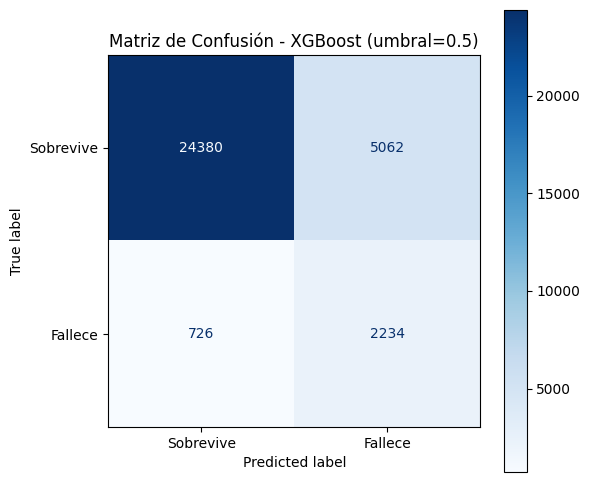

              precision    recall  f1-score   support

   Sobrevive       0.97      0.83      0.89     29442
     Fallece       0.31      0.75      0.44      2960

    accuracy                           0.82     32402
   macro avg       0.64      0.79      0.66     32402
weighted avg       0.91      0.82      0.85     32402



In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sobrevive', 'Fallece'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión - {nombre_ganador} (umbral=0.5)')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Sobrevive', 'Fallece']))

### 4.7. Curva de Calibración del Modelo Ganador

La curva de calibración compara la probabilidad predicha media con la frecuencia observada real de la clase positiva, agrupando las predicciones en 10 cuantiles (`strategy='quantile'`) para tener un número comparable de observaciones en cada punto pese al desbalanceo de clases.

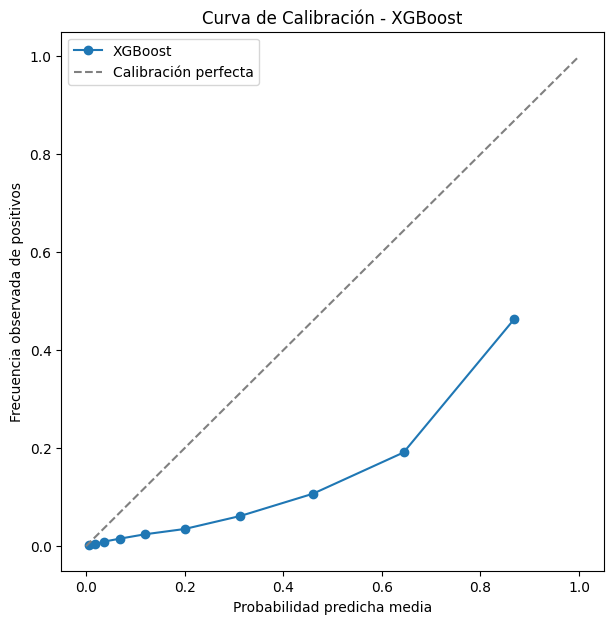

In [18]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred, prob_true, marker='o', label=nombre_ganador)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha media')
ax.set_ylabel('Frecuencia observada de positivos')
ax.set_title(f'Curva de Calibración - {nombre_ganador}')
ax.legend()
plt.show()

## 5. Interpretabilidad: Análisis SHAP del Modelo Ganador

Se emplea SHAP (*SHapley Additive exPlanations*) para cuantificar la contribución de cada variable a las predicciones individuales del modelo ganador. Este análisis es clave para la discusión clínica del TFG: permite identificar qué variables (edad, scores APACHE/APS, comorbilidades, constantes vitales) pesan más en la predicción de mortalidad, y en qué dirección.

Por coste computacional, los valores SHAP se calculan sobre una submuestra del conjunto de test (no afecta a la validez del análisis interpretativo, solo a la precisión de las estimaciones agregadas).

In [21]:
print(f"Calculando valores SHAP para el modelo ganador: {nombre_ganador}...")

# NOTA TÉCNICA: el cálculo SHAP se ejecuta en un subproceso de Python aislado. En este
# entorno concreto, `import shap` se queda colgado de forma reproducible si se ejecuta en
# el mismo kernel de Jupyter que ya ha entrenado los 3 modelos (conflicto de bajo nivel
# entre la inicialización de numba y el runtime del kernel en Windows). Ejecutarlo en un
# proceso nuevo evita el problema sin afectar a la validez del resultado: el subproceso
# recibe el modelo ya entrenado y la misma muestra de test.
#
# El tamaño de muestra (200) se eligió tras medir el coste real: si el ganador es Random
# Forest, sus árboles no tienen profundidad máxima limitada (profundidad media ~54,
# ~12.700 hojas/árbol sobre este dataset), y el cálculo exacto de SHAP cuesta ~1.9s por
# fila (~6 min para 200 filas). Con XGBoost o Regresión Logística el mismo cálculo es casi
# instantáneo. 200 observaciones siguen siendo representativas para el análisis agregado.

shap_tmp_dir = tempfile.mkdtemp(prefix='shap_iso_')
sample_size = min(200, X_test.shape[0])
X_shap_sample = X_test.sample(n=sample_size, random_state=42)

joblib.dump(modelo_ganador, os.path.join(shap_tmp_dir, 'modelo.joblib'))
joblib.dump(X_shap_sample, os.path.join(shap_tmp_dir, 'X_shap_sample.joblib'))
joblib.dump(
    X_train.sample(n=min(1000, X_train.shape[0]), random_state=42),
    os.path.join(shap_tmp_dir, 'X_background.joblib')
)

worker_script = os.path.join(shap_tmp_dir, 'shap_worker.py')
with open(worker_script, 'w', encoding='utf-8') as f:
    f.write(f'''
import os
os.environ['NUMBA_DISABLE_JIT'] = '1'
import joblib
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shap

tmp_dir = r"{shap_tmp_dir}"
nombre_ganador = "{nombre_ganador}"

modelo = joblib.load(os.path.join(tmp_dir, 'modelo.joblib'))
X_shap_sample = joblib.load(os.path.join(tmp_dir, 'X_shap_sample.joblib'))

modelos_arbol = ['Random Forest', 'XGBoost']
if nombre_ganador in modelos_arbol:
    explainer = shap.TreeExplainer(modelo)
else:
    X_background = joblib.load(os.path.join(tmp_dir, 'X_background.joblib'))
    explainer = shap.LinearExplainer(modelo, X_background)

shap_values = explainer(X_shap_sample)
sv = shap_values.values
sv_plot = sv[:, :, 1] if sv.ndim == 3 else sv

np.save(os.path.join(tmp_dir, 'sv_plot.npy'), sv_plot)

shap.summary_plot(sv_plot, X_shap_sample, show=False)
plt.title(f'SHAP Summary Plot - {{nombre_ganador}}')
plt.tight_layout()
plt.savefig(os.path.join(tmp_dir, 'shap_summary.png'), dpi=120, bbox_inches='tight')
plt.close()

shap.summary_plot(sv_plot, X_shap_sample, plot_type='bar', show=False)
plt.title(f'Importancia media |SHAP| - {{nombre_ganador}}')
plt.tight_layout()
plt.savefig(os.path.join(tmp_dir, 'shap_bar.png'), dpi=120, bbox_inches='tight')
plt.close()

print("SHAP_WORKER_OK", sv_plot.shape)
''')

print("Ejecutando subproceso de cálculo SHAP (puede tardar varios minutos si el ganador es Random Forest)...")
resultado_shap = subprocess.run(
    [sys.executable, worker_script], capture_output=True, text=True, timeout=1800
)

if resultado_shap.returncode != 0:
    print(resultado_shap.stdout)
    print(resultado_shap.stderr)
    raise RuntimeError("El subproceso de cálculo SHAP falló. Ver salida arriba.")

sv_plot = np.load(os.path.join(shap_tmp_dir, 'sv_plot.npy'))

print(f"Valores SHAP calculados sobre una muestra de {sample_size} observaciones de test.")
print(f"Forma de la matriz de valores SHAP: {sv_plot.shape}")

Calculando valores SHAP para el modelo ganador: XGBoost...
Ejecutando subproceso de cálculo SHAP (puede tardar varios minutos si el ganador es Random Forest)...
Valores SHAP calculados sobre una muestra de 200 observaciones de test.
Forma de la matriz de valores SHAP: (200, 141)


### 5.1. Gráfico Resumen SHAP (*Beeswarm*)

Cada punto representa una observación de la submuestra. La posición horizontal indica el impacto de esa variable en la predicción (positivo = empuja hacia mayor riesgo de mortalidad); el color indica si el valor de la variable es alto (rojo) o bajo (azul) para esa observación.

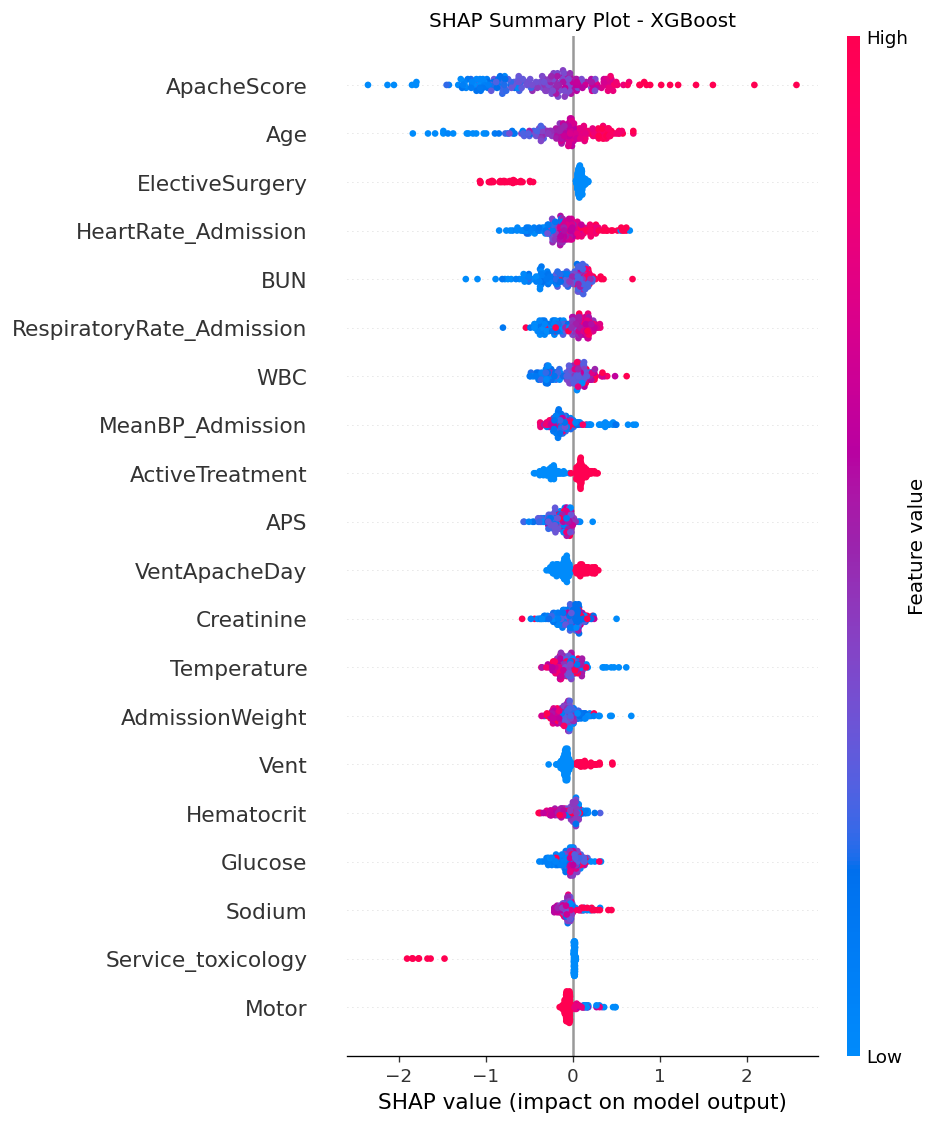

In [22]:
from IPython.display import Image
display(Image(filename=os.path.join(shap_tmp_dir, 'shap_summary.png')))

### 5.2. Importancia Media de Variables (|SHAP|)

Ranking de variables según la magnitud media absoluta de su contribución, independientemente del signo (dirección) del efecto.

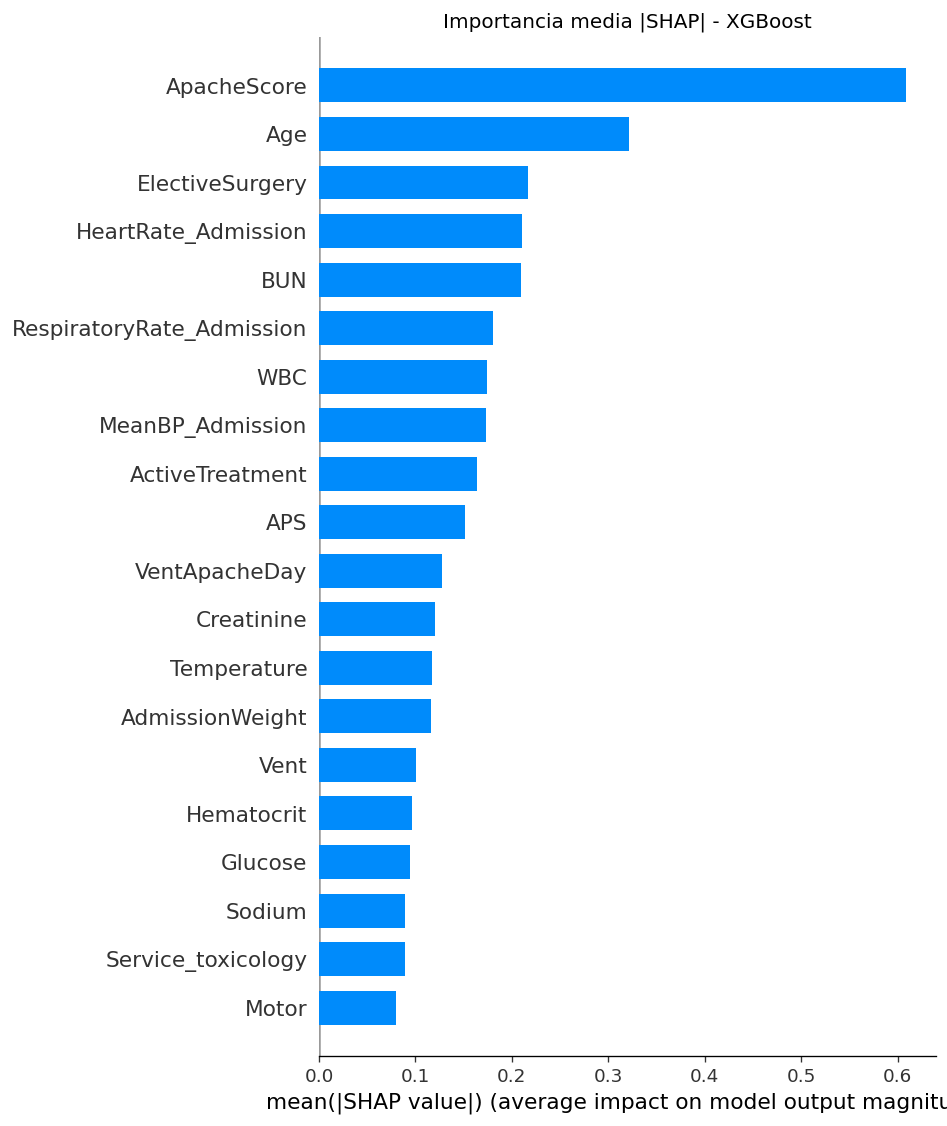

In [23]:
display(Image(filename=os.path.join(shap_tmp_dir, 'shap_bar.png')))

## 6. Ajuste del Umbral de Decisión (Curva Precision-Recall)

El umbral de clasificación por defecto (0.5) no tiene por qué ser el óptimo desde el punto de vista clínico: en un contexto de mortalidad en UCI, un falso negativo (no detectar un paciente de alto riesgo) suele ser más costoso que un falso positivo. La curva Precision-Recall permite explorar el trade-off entre sensibilidad (recall) y precisión en función del umbral, y elegir un punto de operación distinto al 0.5 por defecto.

Como referencia se calcula el umbral que maximiza el F1-score (equilibrio entre precisión y recall), aunque en la práctica clínica el punto de operación final debería fijarse según el coste relativo real de cada tipo de error, no únicamente por F1.

Umbral que maximiza F1-score: 0.7329
Precision en ese umbral: 0.4513
Recall en ese umbral: 0.5311
F1-score en ese umbral: 0.4880


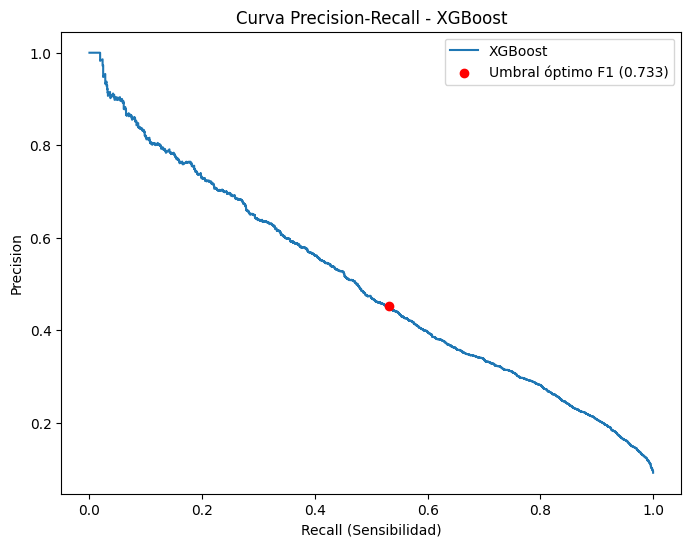

In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# F1-score en cada punto de la curva (excluyendo el último, sin umbral asociado)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
idx_best_f1 = np.argmax(f1_scores)
umbral_optimo_f1 = thresholds[idx_best_f1]

print(f"Umbral que maximiza F1-score: {umbral_optimo_f1:.4f}")
print(f"Precision en ese umbral: {precision[idx_best_f1]:.4f}")
print(f"Recall en ese umbral: {recall[idx_best_f1]:.4f}")
print(f"F1-score en ese umbral: {f1_scores[idx_best_f1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, label=nombre_ganador)
ax.scatter(
    recall[idx_best_f1], precision[idx_best_f1],
    color='red', zorder=5, label=f'Umbral óptimo F1 ({umbral_optimo_f1:.3f})'
)
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precision')
ax.set_title(f'Curva Precision-Recall - {nombre_ganador}')
ax.legend()
plt.show()

### 6.1. Comparación: Umbral por Defecto (0.5) vs. Umbral Ajustado

Se comparan las matrices de confusión y los informes de clasificación resultantes de aplicar el umbral por defecto frente al umbral que maximiza F1, para visualizar el trade-off concreto en número de pacientes.

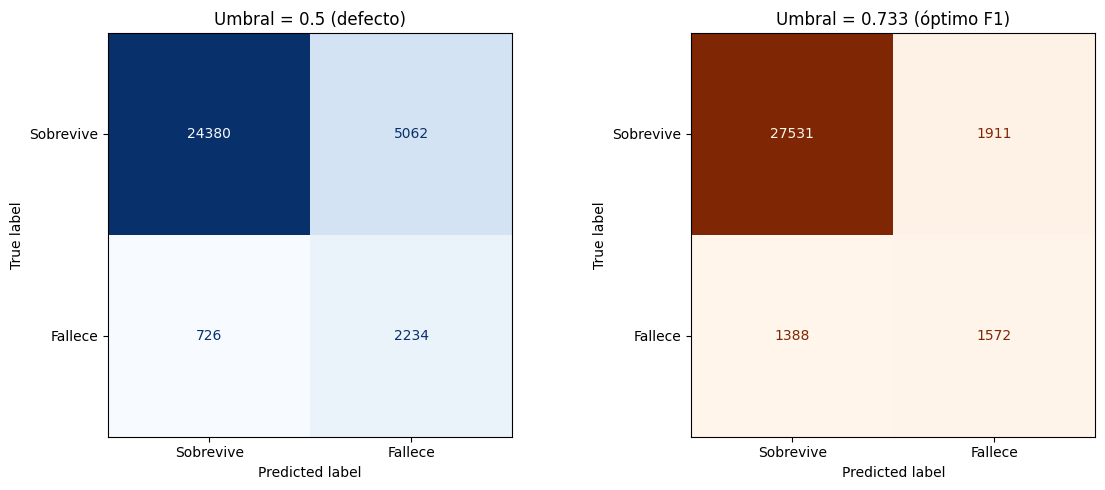

--- Umbral por defecto (0.5) ---
              precision    recall  f1-score   support

   Sobrevive       0.97      0.83      0.89     29442
     Fallece       0.31      0.75      0.44      2960

    accuracy                           0.82     32402
   macro avg       0.64      0.79      0.66     32402
weighted avg       0.91      0.82      0.85     32402

--- Umbral ajustado (0.7329) ---
              precision    recall  f1-score   support

   Sobrevive       0.95      0.94      0.94     29442
     Fallece       0.45      0.53      0.49      2960

    accuracy                           0.90     32402
   macro avg       0.70      0.73      0.72     32402
weighted avg       0.91      0.90      0.90     32402



In [25]:
y_pred_umbral_ajustado = (y_pred_proba >= umbral_optimo_f1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_05 = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_05, display_labels=['Sobrevive', 'Fallece']).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False
)
axes[0].set_title('Umbral = 0.5 (defecto)')

cm_ajustado = confusion_matrix(y_test, y_pred_umbral_ajustado)
ConfusionMatrixDisplay(cm_ajustado, display_labels=['Sobrevive', 'Fallece']).plot(
    ax=axes[1], cmap='Oranges', values_format='d', colorbar=False
)
axes[1].set_title(f'Umbral = {umbral_optimo_f1:.3f} (óptimo F1)')

plt.tight_layout()
plt.show()

print("--- Umbral por defecto (0.5) ---")
print(classification_report(y_test, y_pred, target_names=['Sobrevive', 'Fallece']))

print(f"--- Umbral ajustado ({umbral_optimo_f1:.4f}) ---")
print(classification_report(y_test, y_pred_umbral_ajustado, target_names=['Sobrevive', 'Fallece']))